In [1]:
from typing import TypedDict
from langgraph.graph import StateGraph, START, END
import json

In [2]:
# Define State Schema

class MyState(TypedDict):
    text: str

In [3]:
# Define Node Function

def node_first(state: MyState) -> MyState:
    print("First Node is executing..........")
    return {"text": state['text'] + " -- First Node"}

def node_second(state: MyState) -> MyState:
    print("Second Node is executing..........")
    return {"text": state['text'] + " -- Second Node"}

In [4]:
# Build the graph

graph = StateGraph(MyState)

# Add nodes to the graph
graph.add_node("first", node_first)
graph.add_node("second", node_second)

# Add edges to the graph
graph.add_edge(START, "first")
graph.add_edge("first", "second")
graph.add_edge("second", END)

print("Graph built successfully.")

Graph built successfully.


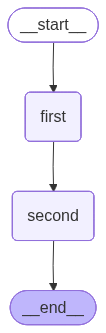

In [5]:
# Compile the graph

app = graph.compile()
app

In [6]:
# Execute the graph
initial_state = {"text": "Hello, World!"}
app.invoke(initial_state)

First Node is executing..........
Second Node is executing..........


{'text': 'Hello, World! -- First Node -- Second Node'}